In [ ]:
House Price Prediction

In [ ]:
Import Modules

In [21]:
#data handling
import pandas as pd
import numpy as np
import math as m

#visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

#ML model, training, evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
Loading the dataset using pandas  &  cleaning it

In [4]:
df=pd.read_csv("Housing.csv")

#First 5 rows help understand structure
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
Handle Missing Values

In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
Encoding the data of the dataset

In [9]:
# Selecting the categorical attributes
categorical_attributes= df.select_dtypes(include="object").columns
categorical_attributes

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [10]:
#Encoding the categorical attributes

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded=df_encoded.astype(int)
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [14]:
independent_varaibles=df_encoded.drop('price',axis=1)
target_varaibles=df['price']

independent_varaibles

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [15]:
target_varaibles

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [ ]:
Implementing linear regression using Scikit-Learn

In [16]:
X_train, X_test, Y_train, Y_test,= train_test_split(independent_varaibles, target_varaibles, test_size=0.2, random_state=42)

In [18]:
#Creating an empty object of LinearRegression class
model=LinearRegression()

#Training the model
model.fit(X_train, Y_train)

#Extacting the coefficients and intercept as well as constructing the equation
intercept=model.intercept_           # Value of the intercept
coefficient=model.coef_             # ndarray of coefficients

#Together they will constitue the equation of the hyperplane
for i in zip(X_train.columns,coefficient):
    print(f"* Feature {i[0]} has coefficient {round(i[1],2)}")
print()

print(f"The intercept is : {round(intercept,2)}")    

* Feature area has coefficient 235.97
* Feature bedrooms has coefficient 76778.7
* Feature bathrooms has coefficient 1094444.79
* Feature stories has coefficient 407476.59
* Feature parking has coefficient 224841.91
* Feature mainroad_yes has coefficient 367919.95
* Feature guestroom_yes has coefficient 231610.04
* Feature basement_yes has coefficient 390251.18
* Feature hotwaterheating_yes has coefficient 684649.89
* Feature airconditioning_yes has coefficient 791426.74
* Feature prefarea_yes has coefficient 629890.57
* Feature furnishingstatus_semi-furnished has coefficient -126881.82
* Feature furnishingstatus_unfurnished has coefficient -413645.06

The intercept is : 260032.36


In [ ]:
Evaluating the models performance on a separate test dataset using metrics such as Mean Squared Error or R-squared.

In [19]:
#Making prediction  on the test dataset
Y_predicted=model.predict(X_test)

#Residuals
residuals= Y_test-Y_predicted
residuals

316   -1.104654e+06
77    -5.747223e+05
360    6.001368e+05
90     1.827925e+06
493   -4.946463e+05
           ...     
15     4.126669e+06
357   -5.636509e+05
39     8.509373e+05
54     9.510591e+05
155   -8.338899e+05
Name: price, Length: 109, dtype: float64

In [22]:
#Calculating the errors: MSE
mse=mean_squared_error(Y_test, Y_predicted)
rmse=m.sqrt(mse)
r2 = r2_score(Y_test, Y_predicted)

#Printing the results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 1754318687330.66
Root Mean Squared Error (RMSE): 1324506.96
R-squared (R²): 0.65


In [ ]:
Creating visualizations to illustrate the relationship between the predicted and actual values

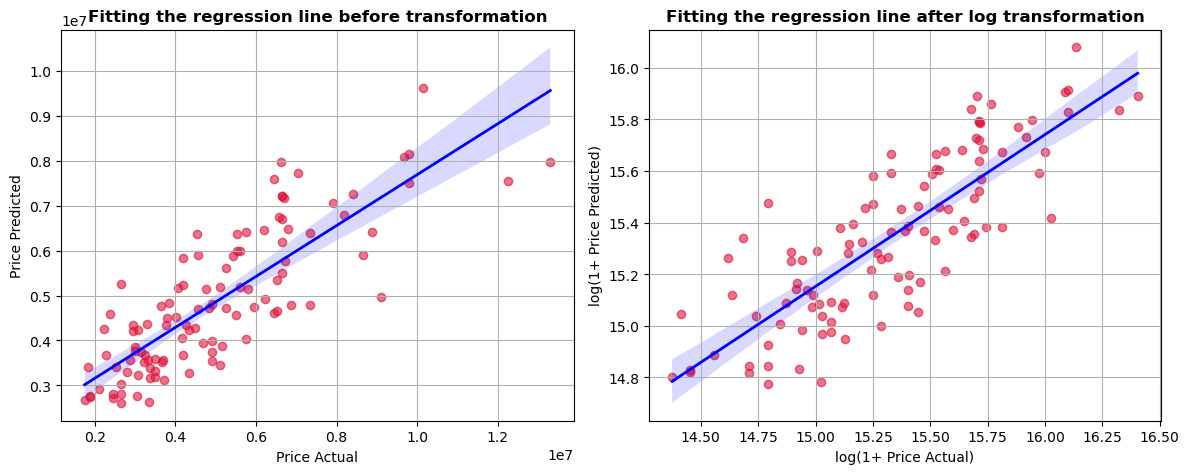

In [24]:
#Regression line for predicted price vs actual price
fig, axes=plt.subplots(1,2,figsize=(12,5))
sns.regplot(x=Y_test,y=Y_predicted,color="red",scatter_kws={"color": "crimson", "alpha": 0.6}, line_kws={"color": "blue", "linewidth": 2},ax=axes[0])

axes[0].set_xlabel("Price Actual")
axes[0].set_ylabel("Price Predicted")
axes[0].set_title("Fitting the regression line before transformation",fontweight='bold')
axes[0].grid(True)

sns.regplot(x=np.log1p(Y_test),y=np.log1p(Y_predicted),color="red",scatter_kws={"color": "crimson", "alpha": 0.6}, line_kws={"color": "blue", "linewidth": 2},ax=axes[1])

axes[1].set_xlabel("log(1+ Price Actual)")
axes[1].set_ylabel("log(1+ Price Predicted)")
axes[1].set_title("Fitting the regression line after log transformation",fontweight='bold')
axes[1].grid(True)

plt.tight_layout()
plt.show()

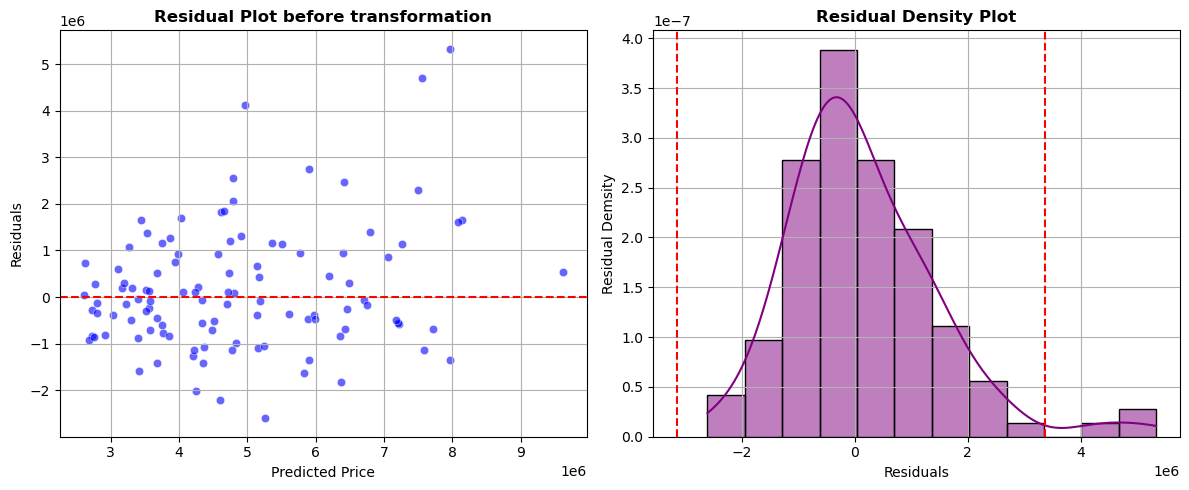

In [27]:
#Residual Plot analysis
fig, axes= plt.subplots(1,2,figsize=(12,5))
sns.scatterplot(x=Y_predicted, y=residuals, color='blue', alpha=0.6, ax=axes[0])

axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot before transformation",fontweight='bold')
axes[0].grid(True)

#Outlier and distribution function building
from scipy.stats import skew
Q1= residuals.quantile(0.25)
Q3= residuals.quantile(0.75)

IQR=Q3-Q1

lower_bound= Q1-1.5*IQR
upper_bound= Q3+1.5*IQR

#Creating a boolean mask
outliers_mask= (residuals< lower_bound) | (residuals> upper_bound)

#Obtaining the outliers
outliers= residuals[outliers_mask]

sns.histplot(residuals, stat='density', kde=True, color= 'purple')
axes[1].axvline(lower_bound , color='red', linestyle='--')
axes[1].axvline(upper_bound , color='red', linestyle='--')
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Residual Demsity")
axes[1].set_title("Residual Density Plot",fontweight='bold')
axes[1].grid(True)

plt.tight_layout()
plt.show()

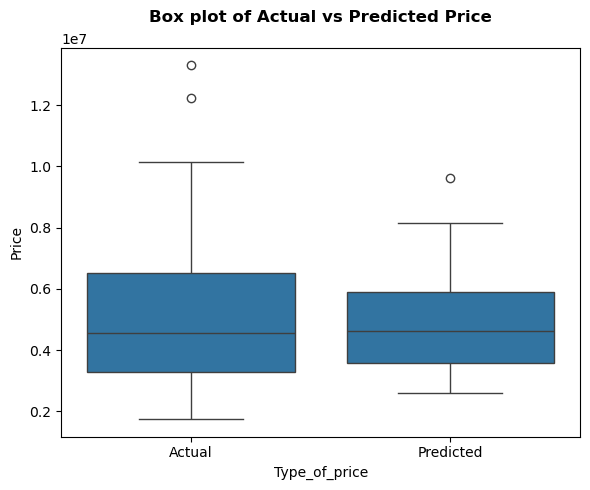

In [31]:
#Box plot of actual vs predicted prices
plt.figure(figsize=(6,5))
df_comparison= pd.DataFrame({"Actual": Y_test, "Predicted": Y_predicted})
df_melted= df_comparison.melt(var_name="Type_of_price", value_name="Price")

sns.boxplot(x='Type_of_price', y='Price', data= df_melted)
plt.title("Box plot of Actual vs Predicted Price\n",fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
#Comparing dual attributes simultaneously
df_encoded.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

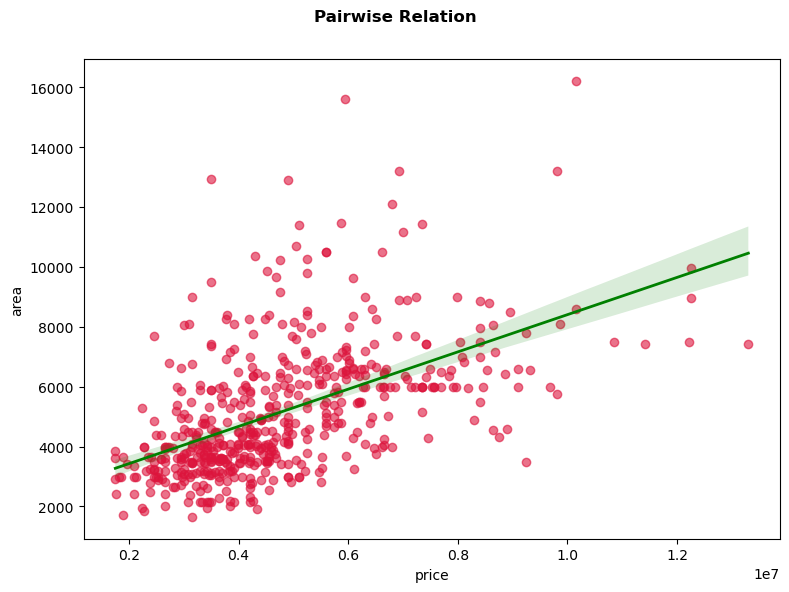

In [33]:
features=['price','area']
plt.figure(figsize=(8,6))
sns.regplot(x=df_encoded[features[0]], y=df_encoded[features[1]],scatter_kws={"color": "crimson", "alpha": 0.6}, line_kws={"color": "green", "linewidth": 2})
plt.suptitle("Pairwise Relation\n",fontweight='bold')
plt.tight_layout()
plt.show()

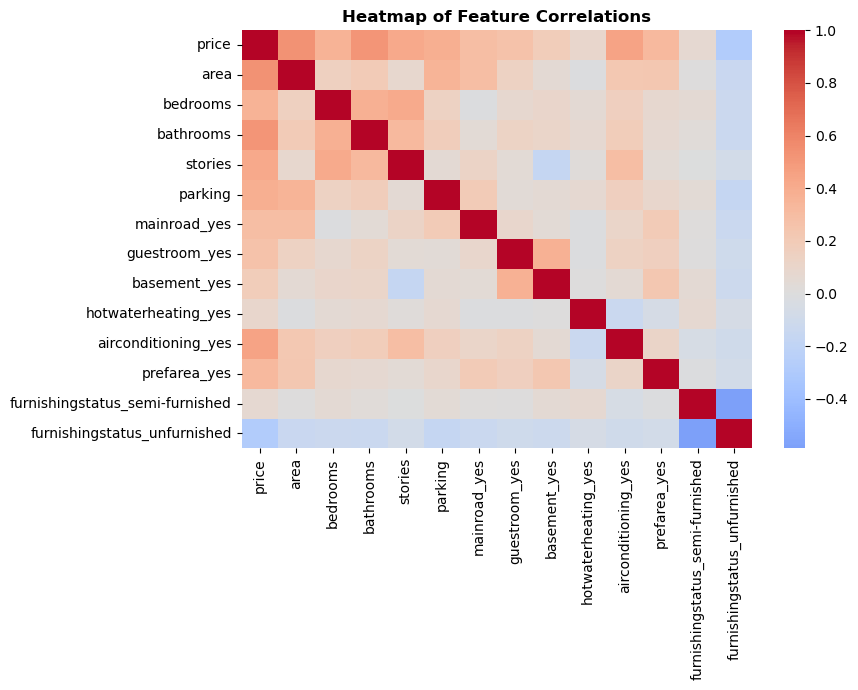

In [34]:
# Heatmap of Feature Correlations
plt.figure(figsize=(9,7))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False, center=0)
plt.title("Heatmap of Feature Correlations",fontweight='bold')
plt.tight_layout()